In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('global air pollution dataset.csv')
# source - https://www.kaggle.com/datasets/hasibalmuzdadid/global-air-pollution-dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [8]:
df

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate


In [12]:
df.nunique()

Country                 175
City                  23462
AQI Value               347
AQI Category              6
CO AQI Value             34
CO AQI Category           3
Ozone AQI Value         213
Ozone AQI Category        5
NO2 AQI Value            59
NO2 AQI Category          2
PM2.5 AQI Value         383
PM2.5 AQI Category        6
dtype: int64

In [16]:
df = df.dropna()

In [37]:
sum(df.duplicated())

0

In [17]:
columns = df.columns

In [19]:
columns

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')

In [22]:
num_cols = df.select_dtypes(include=['int', 'float']).columns
cat_cols = df.select_dtypes(exclude=['int', 'float']).columns

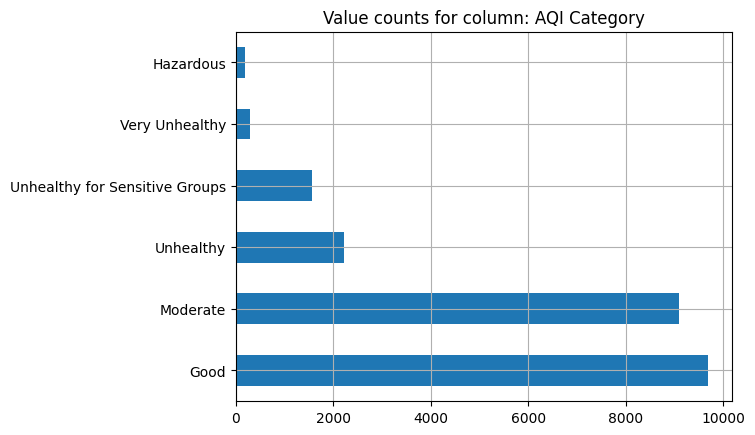

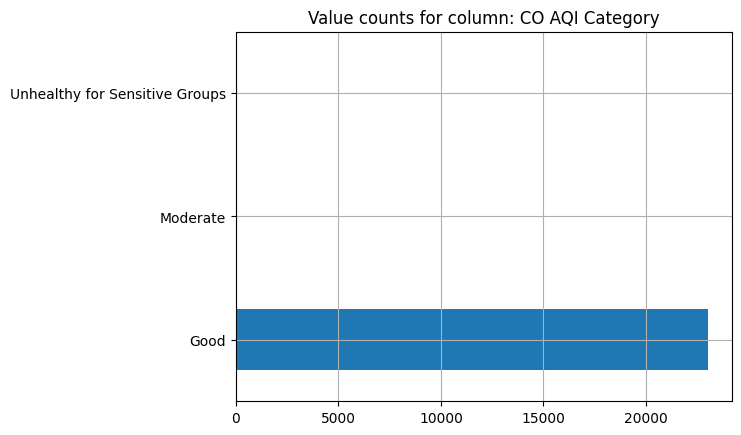

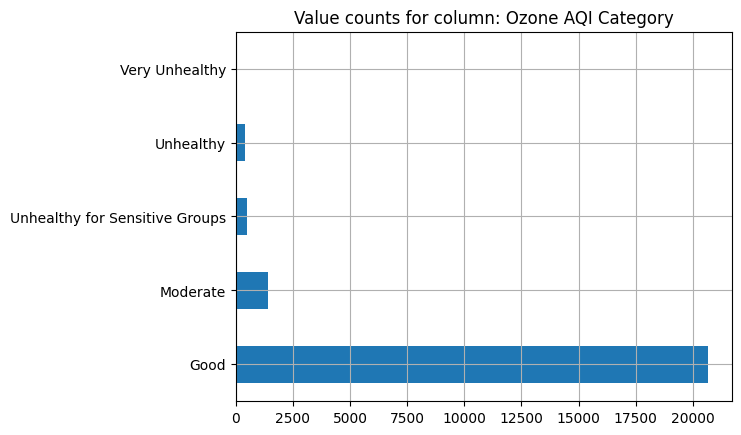

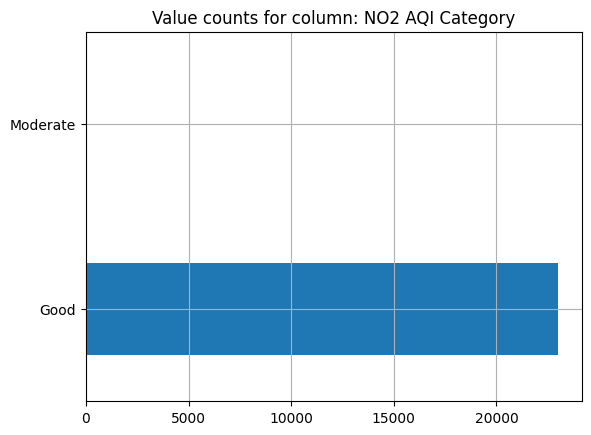

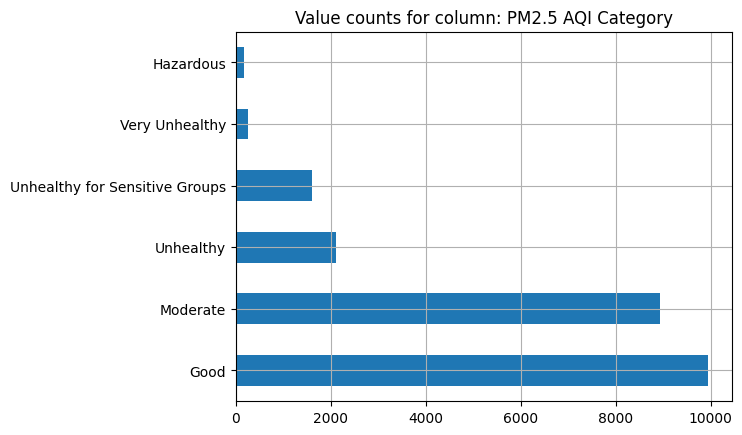

In [40]:
for col in cat_cols:
    if col in ['City', 'Country']:
        continue
    df[col].value_counts().plot.barh()
    plt.title(f'Value counts for column: {col}')
    plt.ylabel('')
    plt.grid()
    plt.show()

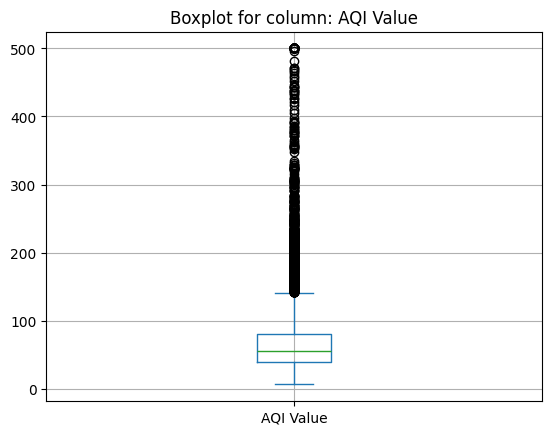

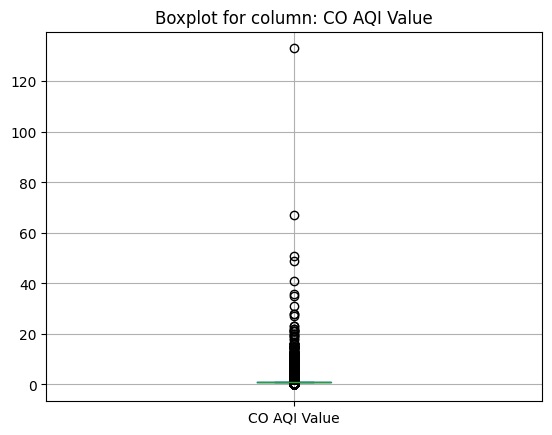

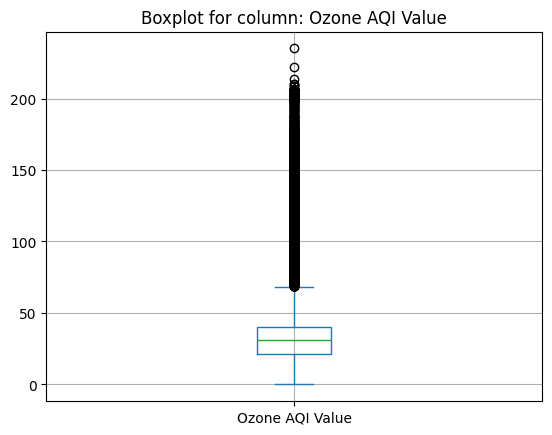

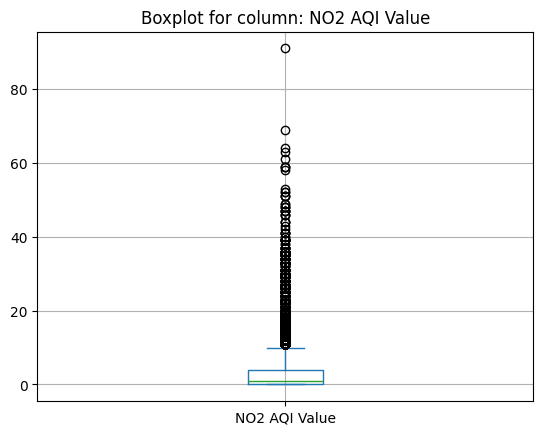

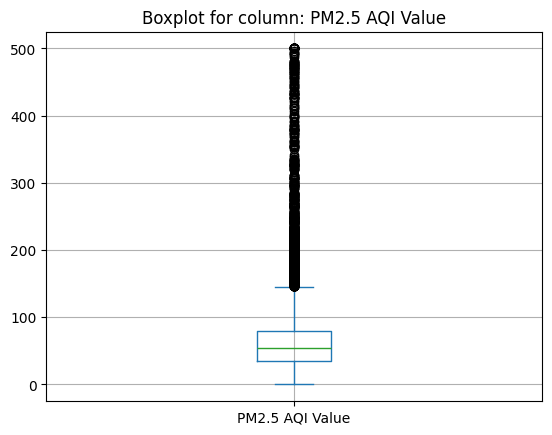

In [50]:
for col in num_cols:
    df[col].plot.box()
    plt.title(f'Boxplot for column: {col}')
    plt.grid()
    plt.show()

In [97]:
def count_outliers(data):
    outliers = {'3sigma lowers': [],
                '3sigma uppers': [],
                'total 3sigma outliers': [],
                '% 3sigma outliers of total examples': [],
                '1.5IQR lowers': [],
                '1.5IQR uppers': [],
                'total 1.5IQR outliers': [],
                '% 1.5IQR outliers of total examples': []}

    n_examples = data.shape[0]
    
    for col in data.columns:
        std = data[col].std()
        mean = data[col].mean()
        sigma_lowers = sum(data[col] < mean - 3 * std)
        outliers['3sigma lowers'].append(sigma_lowers)
        sigma_uppers = sum(data[col] > mean + 3 * std)
        outliers['3sigma uppers'].append(sigma_uppers)
        sigma_total = sigma_lowers + sigma_uppers
        outliers['total 3sigma outliers'].append(sigma_total)
        outliers['% 3sigma outliers of total examples'].append(round((sigma_total / n_examples)*100, 1))
    
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        iqr_lowers = sum(data[col] < q1 - 1.5 * iqr)
        outliers['1.5IQR lowers'].append(iqr_lowers)
        iqr_uppers = sum(data[col] > q3 + 1.5 * iqr)
        outliers['1.5IQR uppers'].append(iqr_uppers)
        iqr_total = iqr_lowers + iqr_uppers
        outliers['total 1.5IQR outliers'].append(iqr_total)
        outliers['% 1.5IQR outliers of total examples'].append(round((iqr_total / n_examples)*100, 1))

    result = pd.DataFrame(outliers)
    result.index = data.columns

    return result

In [98]:
count_outliers(df[num_cols])

,3sigma lowers,3sigma uppers,total 3sigma outliers,% 3sigma outliers of total examples,1.5IQR lowers,1.5IQR uppers,total 1.5IQR outliers,% 1.5IQR outliers of total examples
AQI Value,0,271,271,1.2,0,2875,2875,12.5
CO AQI Value,0,265,265,1.2,3008,5434,8442,36.6
Ozone AQI Value,0,749,749,3.3,0,1500,1500,6.5
NO2 AQI Value,0,593,593,2.6,0,1670,1670,7.2
PM2.5 AQI Value,0,283,283,1.2,0,2628,2628,11.4


In [109]:
n_cities_per_country = df.groupby('Country').size().sort_values()

In [113]:
n_cities_per_country.head(50)

Country
Saint Lucia                          1
Palau                                1
Seychelles                           1
Solomon Islands                      1
Barbados                             1
Monaco                               1
Bahrain                              1
Republic of Korea                    1
Maldives                             1
Vanuatu                              1
Singapore                            1
Saint Kitts and Nevis                1
Aruba                                1
State of Palestine                   1
Cabo Verde                           2
Bhutan                               2
Qatar                                2
Luxembourg                           2
Comoros                              3
Kuwait                               3
Kingdom of Eswatini                  3
Suriname                             3
Belize                               3
United Arab Emirates                 3
Andorra                              3
Iceland          

In [112]:
n_cities_per_country.tail(50)

Country
Côte d'Ivoire                                             67
Argentina                                                 68
Austria                                                   68
Democratic Republic of the Congo                          70
Kazakhstan                                                71
Bangladesh                                                80
Finland                                                   81
Chile                                                     81
Ethiopia                                                  82
Australia                                                 85
Serbia                                                    89
Venezuela (Bolivarian Republic of)                        90
Sweden                                                    97
Cuba                                                      98
Greece                                                   104
Switzerland                                              116
Guatemala       

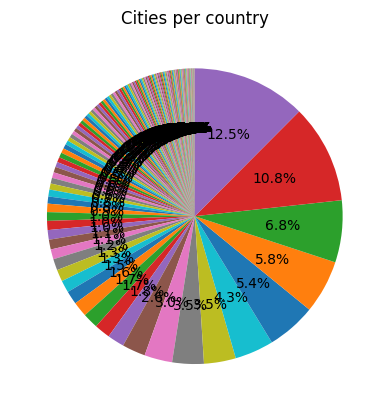

In [122]:
plt.pie(n_cities_per_country, autopct='%1.1f%%', startangle=90)

plt.title('Cities per country')
plt.show()